STEP 1: Setup & Load Data

In [1]:
!pip install pandas numpy nltk scikit-learn

In [2]:
import pandas as pd
import numpy as np
import nltk

In [6]:
df = pd.read_csv("IMDB Dataset.csv")

Validate Dataset

In [7]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
df.shape

(50000, 2)

In [9]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [10]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


STEP 2: Data Understanding

In [11]:
df.isnull().sum()

,0
review,0
sentiment,0


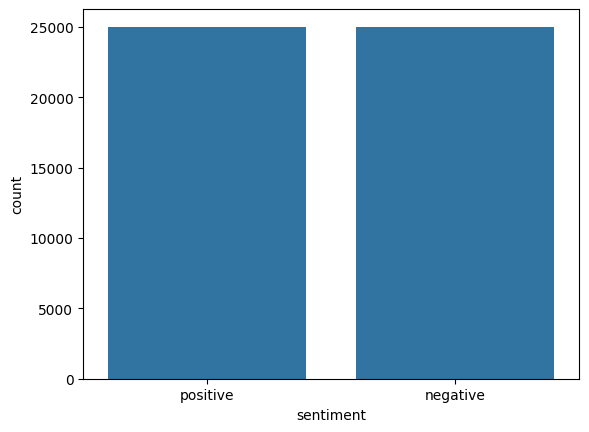

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.show()

Dataset is balanced

In [15]:
print(df['review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

Text is raw
Contains punctuation, stopwords, etc.

STEP 3: NLP Preprocessing

In [17]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [18]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z]", " ", text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

Apply Preprocessing

In [19]:
df['clean_text'] = df['review'].apply(preprocess_text)

Validate Output

In [20]:
print("Before:\n", df['review'][0])
print("\nAfter:\n", df['clean_text'][0])

Before:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due t

STEP 4: Feature Engineering

Target Variable

In [21]:
y = df['sentiment']

Bag of Words

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text'])

TF-IDF

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

Validate Features

In [24]:
X_tfidf.shape

(50000, 5000)

STEP 5: Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

STEP 6: Model Building

1. Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

2. Naive Bayes

In [27]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

3. Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

STEP 7: Evaluation

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }

lr_results = evaluate(y_test, y_pred_lr)
nb_results = evaluate(y_test, y_pred_nb)
dt_results = evaluate(y_test, y_pred_dt)

STEP 8: Comparison Table

In [31]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    "Accuracy": [lr_results["Accuracy"], nb_results["Accuracy"], dt_results["Accuracy"]],
    "F1 Score": [lr_results["F1 Score"], nb_results["F1 Score"], dt_results["F1 Score"]]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.8893,0.889267
1,Naive Bayes,0.8560,0.855987
2,Decision Tree,0.7199,0.719898


Step 9: Insights

1. Logistic Regression achieved the highest performance with an accuracy of 88.93% and F1 score of 0.889, making it the best-performing model for this task.
2. Naive Bayes also performed well with an accuracy of 85.60%, but slightly lower than Logistic Regression.
3. Decision Tree showed significantly lower performance with an accuracy of 71.99%, indicating poor generalization.

Conclusion

1. Logistic Regression is the most suitable model for this sentiment analysis task.
2. TF-IDF + Logistic Regression forms an effective baseline NLP pipeline.
3. Tree-based models require further tuning or ensemble methods (like Random Forest) to perform better on text data.